# MACE-POLAR-1 — Complete GSCDB Datatype Benchmark

This notebook benchmarks **one complete GSCDB Datatype** at a time with:

- `mace-polar-1-s`
- `mace-polar-1-m`
- `mace-polar-1-l`

It is designed for the six GSCDB **energy Datatypes**:

- Barrier Height
- Intramolecular Noncovalent
- Isomerization
- Noncovalent
- Thermochemistry
- Transition Metal

For the selected Datatype it will:

1. Read every Dataset belonging to that Datatype from `../Info/Datasets.csv`.
2. Read every required molecular structure from the stoichiometries in `../Info/DatasetEval.csv`.
3. Generate MACE-POLAR molecular energies for all unique molecules.
4. Reconstruct every GSCDB energy difference for all three MACE-POLAR variants.
5. Calculate pooled Datatype MAE and RMSE for the correlation plots.
6. Reproduce the `analyze.ipynb` dataset-level benchmark metric.
7. Calculate each Dataset's **Normalized Error Ratio (NER)**:
   `NER = Dataset metric error / Standard_errors.csv Metric`
8. Calculate the complete Datatype **Mean Relative Error (MRE)** as the arithmetic mean of the Dataset-level NER values.
9. Validate the DFT comparator's NER/MRE against the existing GSCDB `Relative_metric_per_set.csv` and `Statistical_errors.csv`.
10. Add MACE-POLAR columns to new copies of the error/relative/statistical files and verify the MACE-POLAR MRE.
11. Generate three complete-Datatype correlation plots:
    - Reference vs both wB97M-V and MACE-POLAR-1-S
    - Reference vs both wB97M-V and MACE-POLAR-1-M
    - Reference vs both wB97M-V and MACE-POLAR-1-L

### Important aggregation distinction

- **MAE/RMSE on the plot** are pooled over all individual points in the selected Datatype.
- **Mean Relative Error** is *not* pooled over points. It is the equal-weight arithmetic mean of Dataset-level NER values, matching `analyze.ipynb`.

The fixed `../Info/Standard_errors.csv` baseline is **not recomputed after adding MACE-POLAR**.


In [1]:
# ============================================================
# 1. USER SETTINGS — CHANGE THIS DATATYPE ONLY
# ============================================================

SELECTED_DATATYPE = "Barrier Height"
COMPARATOR = "wB97M-V"

MODEL_MAP = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

SUPPORTED_ENERGY_DATATYPES = {
    "Barrier Height",
    "Intramolecular Noncovalent",
    "Isomerization",
    "Noncovalent",
    "Thermochemistry",
    "Transition Metal",
}

DEFAULT_DTYPE = "float64"
FORCE_CPU = False
STRICT_COMPLETE_DATATYPE = True
SAVE_PLOTS = True
PLOT_DPI = 300

HARTREE_TO_KCAL_MOL = 627.50947406
EV_TO_HARTREE = 1.0 / 27.211386245988

print("Selected Datatype:", SELECTED_DATATYPE)
print("Comparator:", COMPARATOR)
print("MACE-POLAR models:", list(MODEL_MAP))


Selected Datatype: Barrier Height
Comparator: wB97M-V
MACE-POLAR models: ['mace-polar-1-s', 'mace-polar-1-m', 'mace-polar-1-l']


In [2]:
# ============================================================
# 2. IMPORTS, PROJECT PATHS, GPU
# ============================================================

from pathlib import Path
import re
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from ase.io import read

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

cwd = Path.cwd().resolve()

if (cwd / "Info").exists() and (cwd / "Analysis").exists():
    PROJECT_DIR = cwd
elif cwd.name == "Analysis" and (cwd.parent / "Info").exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError(
        "Could not identify the GSCDB Benchmarking project root. "
        "Open the GSCDB Benchmarking folder in VS Code, then run this notebook "
        "from the project root or its Analysis folder."
    )

ANALYSIS_DIR = PROJECT_DIR / "Analysis"
INFO_DIR = PROJECT_DIR / "Info"
XYZ_DIR = PROJECT_DIR / "xyz_files"
QCHEM_DIR = PROJECT_DIR / "qchem_inputs"

slug = SELECTED_DATATYPE.lower().replace(" ", "_").replace("/", "_")
OUTPUT_DIR = ANALYSIS_DIR / "MACE_POLAR_DATATYPE" / slug
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"

for d in [OUTPUT_DIR, CHECKPOINT_DIR, FIGURE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

DEVICE = "cpu" if FORCE_CPU or not torch.cuda.is_available() else "cuda"

print("Project root :", PROJECT_DIR)
print("Analysis dir :", ANALYSIS_DIR)
print("XYZ dir      :", XYZ_DIR)
print("Output dir   :", OUTPUT_DIR)
print("Device       :", DEVICE)
print("dtype        :", DEFAULT_DTYPE)

if DEVICE == "cuda":
    print("GPU          :", torch.cuda.get_device_name(0))


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root : /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
Analysis dir : /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis
XYZ dir      : /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/xyz_files
Output dir   : /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height
Device       : cuda
dtype        : float64
GPU          : NVIDIA GeForce RTX 3060


In [3]:
# ============================================================
# 3. LOAD GSCDB TABLES AND SELECT THE COMPLETE DATATYPE
# ============================================================

datasets_file = INFO_DIR / "Datasets.csv"
dataset_eval_file = INFO_DIR / "DatasetEval.csv"
results_file = ANALYSIS_DIR / "Results_values.csv"
metric_file = ANALYSIS_DIR / "Errors_per_set_Metric.csv"
relative_file = ANALYSIS_DIR / "Relative_metric_per_set.csv"
statistical_file = ANALYSIS_DIR / "Statistical_errors.csv"
standard_file = INFO_DIR / "Standard_errors.csv"

required = [
    datasets_file, dataset_eval_file, results_file, metric_file,
    relative_file, statistical_file, standard_file
]
for p in required:
    if not p.exists():
        raise FileNotFoundError(f"Required file not found: {p}")

df_datasets = pd.read_csv(datasets_file)
df_eval = pd.read_csv(dataset_eval_file, index_col=0)
df_results_original = pd.read_csv(results_file, index_col=0)
df_metric_original = pd.read_csv(metric_file, index_col=0)
df_relative_original = pd.read_csv(relative_file, index_col=0)
df_statistical_original = pd.read_csv(statistical_file, index_col=0)
df_standard = pd.read_csv(standard_file, index_col=0)

df_datasets["Name"] = df_datasets["Name"].astype(str).str.strip()
df_datasets["Datatype"] = df_datasets["Datatype"].astype(str).str.strip()
df_eval["Dataset"] = df_eval["Dataset"].astype(str).str.strip()
df_results_original["Dataset"] = df_results_original["Dataset"].astype(str).str.strip()
df_metric_original["Datatype"] = df_metric_original["Datatype"].astype(str).str.strip()
df_relative_original["Datatype"] = df_relative_original["Datatype"].astype(str).str.strip()

available_datatypes = sorted(
    x for x in df_datasets["Datatype"].dropna().unique().tolist() if x != "nan"
)

print("Available Datatypes:")
for dt in available_datatypes:
    sub = df_datasets[df_datasets["Datatype"] == dt]
    print(
        f"  {dt:28s} datasets={len(sub):3d}, "
        f"declared points={int(pd.to_numeric(sub['#datapoints']).sum()):4d}"
    )

if SELECTED_DATATYPE not in available_datatypes:
    raise ValueError(
        f"'{SELECTED_DATATYPE}' is not in Datasets.csv. "
        f"Choose one of: {available_datatypes}"
    )

if SELECTED_DATATYPE not in SUPPORTED_ENERGY_DATATYPES:
    raise ValueError(
        f"This notebook intentionally stops for Datatype '{SELECTED_DATATYPE}'. "
        "The same molecular-energy workflow is not sufficient for Electric field "
        "or Frequency because those Datatypes require property-specific handling."
    )

datatype_rows = df_datasets[df_datasets["Datatype"] == SELECTED_DATATYPE].copy()
DATATYPE_DATASETS = datatype_rows["Name"].drop_duplicates().tolist()

df_eval_sel = df_eval[df_eval["Dataset"].isin(DATATYPE_DATASETS)].copy()
df_results_sel_base = df_results_original[
    df_results_original["Dataset"].isin(DATATYPE_DATASETS)
].copy()

if COMPARATOR not in df_results_sel_base.columns:
    raise KeyError(f"Comparator '{COMPARATOR}' not found in Results_values.csv")

expected_from_metadata = int(pd.to_numeric(datatype_rows["#datapoints"]).sum())

print("\nSelected Datatype:", SELECTED_DATATYPE)
print("Datasets:", len(DATATYPE_DATASETS))
print("DatasetEval rows:", len(df_eval_sel))
print("Results_values rows:", len(df_results_sel_base))
print("Declared points from Datasets.csv:", expected_from_metadata)

display(
    datatype_rows[
        ["Name", "Datatype_Short", "Datatype", "Description", "#datapoints", "Theory level"]
    ].reset_index(drop=True)
)

if STRICT_COMPLETE_DATATYPE:
    if len(df_eval_sel) != expected_from_metadata:
        raise ValueError("DatasetEval row count does not equal Datasets.csv #datapoints total.")
    if len(df_results_sel_base) != expected_from_metadata:
        raise ValueError("Results_values row count does not equal Datasets.csv #datapoints total.")


Available Datatypes:
  Barrier Height               datasets= 12, declared points=1124
  Electric field               datasets=  5, declared points=1171
  Frequency                    datasets=  1, declared points= 275
  Intramolecular Noncovalent   datasets= 10, declared points= 304
  Isomerization                datasets= 11, declared points= 260
  Noncovalent                  datasets= 45, declared points=2942
  Thermochemistry              datasets= 44, declared points=1971
  Transition Metal             datasets=  9, declared points= 330

Selected Datatype: Barrier Height
Datasets: 12
DatasetEval rows: 1124
Results_values rows: 1124
Declared points from Datasets.csv: 1124


,Name,Datatype_Short,Datatype,Description,#datapoints,Theory level
0,BH28,BH,Barrier Height,"Highly accurate subset chosen from BHPERI, CRB...",28.0,W3lite-F12
1,BH46,BH,Barrier Height,"Barrier heights of hydrogen transfer, heavy at...",46.0,W2-F12
2,BH876,BH,Barrier Height,Comprehensive reaction barrier heights,876.0,HF/a[TQ]Z+MP2/a[TQ]Z+DLPNO-CCSD(T) /aTZ/tight
3,BHDIV7,BH,Barrier Height,Diverse reaction barrier heights,7.0,"W1-F12,W2-F12"
4,BHPERI11,BH,Barrier Height,Barrier heights of pericyclic reactions,11.0,"W1-F12,W2-F12"
5,BHROT27,BH,Barrier Height,Barrier heights for rotation around single bonds,27.0,"W1-F12,W2-F12"
6,CRBH14,BH,Barrier Height,Barrier heights for cycloreversion of heterocy...,14.0,W1-F12 and W1w
7,DBH22,BH,Barrier Height,Highly accurate subset of BH76,22.0,W4
8,INV23,BH,Barrier Height,Inversion/Racemization barrier heights,23.0,"W1-F12,W2-F12, DLPNO-CCSD(T)/TightPNO/CBS(def2..."
9,ORBH35,BH,Barrier Height,Difficult barrier heights for oxygen reactions...,35.0,W3X-L


In [4]:
# ============================================================
# 4. FIND EVERY UNIQUE MOLECULE AND READ CHARGE/MULTIPLICITY
# ============================================================

def parse_stoichiometry(stoich):
    parts = [p.strip() for p in str(stoich).split(",")]
    if len(parts) % 2 != 0:
        raise ValueError(f"Malformed stoichiometry: {stoich}")
    return [(float(parts[i]), parts[i + 1]) for i in range(0, len(parts), 2)]

all_molecules = sorted(
    {
        mol
        for stoich in df_eval_sel["Stoichiometry"].dropna()
        for _, mol in parse_stoichiometry(stoich)
    }
)

def parse_xyz_metadata(xyz_path):
    with open(xyz_path, "r", encoding="utf-8") as f:
        f.readline()
        comment = f.readline().strip()

    charge_match = re.search(
        r"\bcharge\s*=\s*([+-]?\d+(?:\.\d+)?)", comment, flags=re.I
    )
    mult_match = re.search(
        r"\bmultiplicity\s*=\s*(\d+)", comment, flags=re.I
    )

    charge = float(charge_match.group(1)) if charge_match else None
    multiplicity = int(mult_match.group(1)) if mult_match else None
    return charge, multiplicity

def parse_qchem_charge_mult(qchem_path):
    # Fallback: first non-empty line after $molecule should be charge multiplicity.
    text = Path(qchem_path).read_text(encoding="utf-8", errors="ignore").splitlines()
    for i, line in enumerate(text):
        if line.strip().lower() == "$molecule":
            for j in range(i + 1, len(text)):
                s = text[j].strip()
                if not s:
                    continue
                if s.lower() == "$end":
                    break
                m = re.match(r"^\s*([+-]?\d+)\s+(\d+)\s*$", s)
                if m:
                    return float(m.group(1)), int(m.group(2))
                break
    return None, None

molecule_meta = []
missing_xyz = []
missing_state = []

for mol in all_molecules:
    xyz = XYZ_DIR / f"{mol}.xyz"
    qin = QCHEM_DIR / f"{mol}.in"

    if not xyz.exists():
        missing_xyz.append(mol)
        continue

    charge, mult = parse_xyz_metadata(xyz)

    if charge is None or mult is None:
        if qin.exists():
            q_charge, q_mult = parse_qchem_charge_mult(qin)
            charge = charge if charge is not None else q_charge
            mult = mult if mult is not None else q_mult

    if charge is None or mult is None:
        missing_state.append(mol)

    atoms = read(xyz)
    molecule_meta.append(
        {
            "Molecule": mol,
            "num_atoms": len(atoms),
            "charge": charge,
            "multiplicity": mult,
            "xyz_file": str(xyz),
        }
    )

df_molecule_meta = pd.DataFrame(molecule_meta).set_index("Molecule").sort_index()

print("Unique molecules required:", len(all_molecules))
print("XYZ files found:", len(df_molecule_meta))
print("Single-atom structures:", int((df_molecule_meta["num_atoms"] <= 1).sum()))

if missing_xyz:
    print("\nMissing XYZ files:", missing_xyz[:30])
if missing_state:
    print("\nMissing charge/multiplicity:", missing_state[:30])

display(df_molecule_meta.head(20))

if STRICT_COMPLETE_DATATYPE and (missing_xyz or missing_state):
    raise ValueError(
        "The complete Datatype cannot be benchmarked because structures or "
        "electronic-state metadata are missing."
    )

manifest_file = OUTPUT_DIR / "datatype_molecule_manifest.csv"
df_molecule_meta.to_csv(manifest_file)
print("Saved manifest:", manifest_file)


Unique molecules required: 2125
XYZ files found: 2125
Single-atom structures: 15


,num_atoms,charge,multiplicity,xyz_file
Molecule,,,,
11_Rxn1_TS_0cat_WCPT27,5,0.0,1,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
11_c2h4_BH76,6,0.0,1,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
12_Rxn2_TS_0cat_WCPT27,6,0.0,1,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
12_c2h5_lower_BH76,7,0.0,2,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
13_Rxn3_TS_0cat_WCPT27,7,0.0,1,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
13_c2h5ts_BH76,7,0.0,2,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
13react_CRBH20,14,0.0,1,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
13ts_CRBH20,14,0.0,1,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...
14_Rxn4_TS_0cat_WCPT27,7,0.0,1,/home/campus.ncl.ac.uk/c5062080/MScProject/GSC...


Saved manifest: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/datatype_molecule_manifest.csv


In [5]:
# ============================================================
# 5. CALCULATE S/M/L MOLECULAR ENERGIES — RESUMABLE
# ============================================================

from mace.calculators import mace_polar

def calculate_one_model(model_column, checkpoint_name):
    checkpoint_file = CHECKPOINT_DIR / f"{model_column}_molecular_energies.csv"

    if checkpoint_file.exists():
        existing = pd.read_csv(checkpoint_file, index_col=0)
    else:
        existing = pd.DataFrame(
            columns=[
                "num_atoms", "charge", "multiplicity",
                "energy_eV", "energy_Hartree", "status", "error_message"
            ]
        )
        existing.index.name = "Molecule"

    completed = set(
        existing.index[
            existing.get(
                "status",
                pd.Series(index=existing.index, dtype=object)
            ).astype(str).eq("OK")
        ]
    )

    todo = [m for m in all_molecules if m not in completed]

    print(f"\nLoading {checkpoint_name} for {len(todo)} remaining molecules...")
    calc = mace_polar(
        model=checkpoint_name,
        device=DEVICE,
        default_dtype=DEFAULT_DTYPE,
    )

    for mol in tqdm(todo, desc=model_column):
        meta = df_molecule_meta.loc[mol]
        xyz_file = Path(meta["xyz_file"])

        try:
            atoms = read(xyz_file)
            atoms.info["charge"] = float(meta["charge"])
            # multiplicity = number of unpaired electrons + 1
            atoms.info["spin"] = int(meta["multiplicity"])
            atoms.info["external_field"] = [0.0, 0.0, 0.0]
            atoms.calc = calc

            energy_eV = float(atoms.get_potential_energy())
            energy_hartree = energy_eV * EV_TO_HARTREE

            existing.loc[mol] = [
                int(meta["num_atoms"]),
                float(meta["charge"]),
                int(meta["multiplicity"]),
                energy_eV,
                energy_hartree,
                "OK",
                "",
            ]

        except Exception as exc:
            existing.loc[mol] = [
                int(meta["num_atoms"]),
                float(meta["charge"]),
                int(meta["multiplicity"]),
                np.nan,
                np.nan,
                "FAILED",
                repr(exc),
            ]

        # frequent checkpointing
        existing.to_csv(checkpoint_file)

    del calc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Saved checkpoint: {checkpoint_file}")
    print(f"Successful: {(existing['status'] == 'OK').sum()}")
    print(f"Failed    : {(existing['status'] == 'FAILED').sum()}")

    if STRICT_COMPLETE_DATATYPE and (existing["status"] != "OK").any():
        failed = existing.index[existing["status"] != "OK"].tolist()
        raise RuntimeError(
            f"{model_column} did not complete the entire Datatype. "
            f"Failed molecules ({len(failed)}): {failed[:30]}"
        )

    return existing.sort_index()

model_energy_tables = {}

for model_column, checkpoint_name in MODEL_MAP.items():
    model_energy_tables[model_column] = calculate_one_model(
        model_column, checkpoint_name
    )

print("\nAll requested model calculations completed.")


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading polar-1-s for 2125 remaining molecules...
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Smodel


mace-polar-1-s: 100%|██████████| 2125/2125 [02:21<00:00, 15.03it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Saved checkpoint: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/checkpoints/mace-polar-1-s_molecular_energies.csv
Successful: 2125
Failed    : 0

Loading polar-1-m for 2125 remaining molecules...
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Mmodel


mace-polar-1-m: 100%|██████████| 2125/2125 [06:09<00:00,  5.75it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Saved checkpoint: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/checkpoints/mace-polar-1-m_molecular_energies.csv
Successful: 2125
Failed    : 0

Loading polar-1-l for 2125 remaining molecules...
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Lmodel


mace-polar-1-l: 100%|██████████| 2125/2125 [14:21<00:00,  2.47it/s]


Saved checkpoint: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/checkpoints/mace-polar-1-l_molecular_energies.csv
Successful: 2125
Failed    : 0

All requested model calculations completed.


In [6]:
# ============================================================
# 6. MERGE S/M/L MOLECULAR ENERGIES
# ============================================================

df_mol_mace = df_molecule_meta[["num_atoms", "charge", "multiplicity"]].copy()

for model_column, table in model_energy_tables.items():
    df_mol_mace[f"{model_column}_eV"] = pd.to_numeric(
        table["energy_eV"], errors="coerce"
    )
    df_mol_mace[f"{model_column}_Hartree"] = pd.to_numeric(
        table["energy_Hartree"], errors="coerce"
    )

combined_molecule_file = OUTPUT_DIR / "Molecule_Energies_MACE_POLAR.csv"
df_mol_mace.to_csv(combined_molecule_file)

print("Saved:", combined_molecule_file)
print("Shape:", df_mol_mace.shape)
display(df_mol_mace.head())


Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/Molecule_Energies_MACE_POLAR.csv
Shape: (2125, 9)


,num_atoms,charge,multiplicity,mace-polar-1-s_eV,mace-polar-1-s_Hartree,mace-polar-1-m_eV,mace-polar-1-m_Hartree,mace-polar-1-l_eV,mace-polar-1-l_Hartree
Molecule,,,,,,,,,
11_Rxn1_TS_0cat_WCPT27,5,0.0,1,-5162.746226,-189.727424,-5162.834351,-189.730663,-5162.892080,-189.732784
11_c2h4_BH76,6,0.0,1,-2137.898466,-78.566320,-2137.900622,-78.566399,-2137.900668,-78.566400
12_Rxn2_TS_0cat_WCPT27,6,0.0,1,-4621.368490,-169.832160,-4621.394714,-169.833123,-4621.413316,-169.833807
12_c2h5_lower_BH76,7,0.0,2,-2153.075642,-79.124070,-2153.105165,-79.125155,-2153.103876,-79.125108
13_Rxn3_TS_0cat_WCPT27,7,0.0,1,-4182.921489,-153.719529,-4182.887645,-153.718286,-4182.886804,-153.718255


In [7]:
# ============================================================
# 7. RECONSTRUCT EVERY ENERGY DIFFERENCE IN THE DATATYPE
#    MIRRORING analyze.ipynb: Hartree -> kcal/mol
# ============================================================

df_model_values = pd.DataFrame(index=df_eval_sel.index)
df_model_values.index.name = "Reaction"
df_model_values["Dataset"] = df_eval_sel["Dataset"]

for model_column in MODEL_MAP:
    hartree_col = f"{model_column}_Hartree"
    values = []

    for reaction_id, row in df_eval_sel.iterrows():
        energy_h = 0.0
        missing = []

        for coeff, mol in parse_stoichiometry(row["Stoichiometry"]):
            if mol not in df_mol_mace.index:
                missing.append(mol)
                continue

            val = pd.to_numeric(
                pd.Series([df_mol_mace.at[mol, hartree_col]]),
                errors="coerce",
            ).iloc[0]

            if pd.isna(val):
                missing.append(mol)
            else:
                energy_h += coeff * float(val)

        values.append(
            np.nan if missing else energy_h * HARTREE_TO_KCAL_MOL
        )

    df_model_values[model_column] = values

df_datatype_values = df_results_sel_base[
    ["Dataset", "Reference", COMPARATOR]
].copy()

missing_reactions = sorted(set(df_eval_sel.index) - set(df_datatype_values.index))
if missing_reactions:
    raise ValueError(
        f"DatasetEval reactions missing from Results_values.csv: {missing_reactions[:30]}"
    )

for model_column in MODEL_MAP:
    df_datatype_values[model_column] = df_model_values.loc[
        df_datatype_values.index, model_column
    ]

if STRICT_COMPLETE_DATATYPE:
    missing_by_model = {
        col: int(df_datatype_values[col].isna().sum())
        for col in MODEL_MAP
        if df_datatype_values[col].isna().any()
    }
    if missing_by_model:
        raise ValueError(f"Incomplete MACE values: {missing_by_model}")

reaction_output_file = OUTPUT_DIR / "Results_values_selected_datatype.csv"
df_datatype_values.to_csv(reaction_output_file)

print("Saved:", reaction_output_file)
print("Rows:", len(df_datatype_values))
display(df_datatype_values.head(20))


Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/Results_values_selected_datatype.csv
Rows: 1124


,Dataset,Reference,wB97M-V,mace-polar-1-s,mace-polar-1-m,mace-polar-1-l
Reaction,,,,,,
BH28_BHDIV_1,BH28,56.955067,56.864131,59.335345,57.014708,58.404544
BH28_BHDIV_2,BH28,50.095602,50.716834,50.771234,50.301826,50.682044
BH28_BHDIV_3,BH28,65.559273,63.827054,68.381784,65.770215,64.355566
BH28_BHPERI_4,BH28,35.014340,36.690550,43.239004,37.783154,36.522503
BH28_BHPERI_5,BH28,30.999044,30.477149,34.177541,30.694018,30.528117
BH28_BHPERI_6,BH28,39.866157,39.489939,47.652939,39.199829,38.505488
BH28_BHPERI_7,BH28,28.489484,26.576103,32.358801,26.834426,26.776386
BH28_BHPERI_8,BH28,37.117591,38.332979,46.582866,40.200371,38.684513
BH28_BHPERI_9,BH28,22.442639,22.574181,28.091388,22.681096,22.550864


In [9]:
# ============================================================
# 8. POOLED COMPLETE-DATATYPE MAE / RMSE
# ============================================================

def pooled_metrics(frame, model_col):
    temp = frame[["Reference", model_col]].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()

    err = temp[model_col].to_numpy() - temp["Reference"].to_numpy()

    return {
        "N_points": len(temp),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MAE": float(np.mean(np.abs(err))),
        "Pearson_r": float(
            np.corrcoef(
                temp["Reference"].to_numpy(),
                temp[model_col].to_numpy()
            )[0, 1]
        ),
    }

pooled_summary = {
    model: pooled_metrics(df_datatype_values, model)
    for model in [COMPARATOR] + list(MODEL_MAP)
}

print("Pooled complete-Datatype metrics:")
for model, vals in pooled_summary.items():
    print(
        f"{model:20s} N={vals['N_points']:4d}  "
        f"RMSE={vals['RMSE']:.8f}  MAE={vals['MAE']:.8f}  "
        f"r={vals['Pearson_r']:.8f}"
    )


Pooled complete-Datatype metrics:
wB97M-V              N=1124  RMSE=1.85618560  MAE=1.34634390  r=0.99546035
mace-polar-1-s       N=1124  RMSE=11.05081925  MAE=6.67092763  r=0.88220271
mace-polar-1-m       N=1124  RMSE=3.78068481  MAE=2.82429150  r=0.98411090
mace-polar-1-l       N=1124  RMSE=2.83767494  MAE=1.98398224  r=0.99014264


In [10]:
# ============================================================
# 9. EXACT analyze.ipynb DATASET-LEVEL METRIC
# ============================================================

tmc_weight_file = INFO_DIR / "DatasetEval_TMC34_weight.csv"
o24_weight_file = INFO_DIR / "DatasetEval_O24x5_weight.csv"

df_tmc_weight = pd.read_csv(tmc_weight_file)
df_o24_weight = pd.read_csv(o24_weight_file)

def exact_gscdb_dataset_metric(dataset_name, errors, references):
    errors = np.asarray(errors, dtype=float)
    references = np.asarray(references, dtype=float)

    # Default metric in analyze.ipynb
    metric_value = float(np.mean(np.abs(errors)))

    # Transition-metal weighted metric
    if dataset_name in ["TMD10", "MOR13", "TMB11"]:
        weight = df_tmc_weight.loc[
            df_tmc_weight["Dataset"].astype(str).str.strip() == dataset_name,
            "Weight",
        ].to_numpy(dtype=float)

        if len(weight) != len(errors) + 1:
            raise ValueError(
                f"{dataset_name}: expected len(weight)=len(errors)+1, "
                f"got {len(weight)} and {len(errors)}"
            )

        metric_value = float(
            np.sum(np.abs(errors) * weight[:-1]) + weight[-1]
        )

    # O24 / O24x4 weighted absolute error
    if dataset_name in ["O24", "O24x4"]:
        weight = df_o24_weight.loc[
            df_o24_weight["Dataset"].astype(str).str.strip() == dataset_name,
            "Weight",
        ].to_numpy(dtype=float)

        if len(weight) != len(errors):
            raise ValueError(
                f"{dataset_name}: expected len(weight)=len(errors), "
                f"got {len(weight)} and {len(errors)}"
            )

        metric_value = float(np.sum(np.abs(errors) * weight))

    return metric_value

df_datatype_errors = df_datatype_values.copy()

for model_column in MODEL_MAP:
    df_datatype_errors[model_column] = (
        pd.to_numeric(df_datatype_values[model_column], errors="coerce")
        - pd.to_numeric(df_datatype_values["Reference"], errors="coerce")
    )

error_output_file = OUTPUT_DIR / "Results_errors_selected_datatype.csv"
df_datatype_errors.to_csv(error_output_file)

rows = []

for dataset_name in DATATYPE_DATASETS:
    sub = df_datatype_errors[
        df_datatype_errors["Dataset"] == dataset_name
    ]

    row = {"Dataset": dataset_name, "Datatype": SELECTED_DATATYPE}

    for model_column in MODEL_MAP:
        valid = sub[["Reference", model_column]].apply(
            pd.to_numeric, errors="coerce"
        ).dropna()

        if STRICT_COMPLETE_DATATYPE and len(valid) != len(sub):
            raise ValueError(
                f"{dataset_name}/{model_column} has "
                f"{len(sub)-len(valid)} missing point(s)."
            )

        row[model_column] = exact_gscdb_dataset_metric(
            dataset_name,
            valid[model_column].to_numpy(),
            valid["Reference"].to_numpy(),
        )

    rows.append(row)

df_metric_mace = pd.DataFrame(rows).set_index("Dataset")
display(df_metric_mace)

df_metric_with_mace = df_metric_original.copy()

for model_column in MODEL_MAP:
    if model_column not in df_metric_with_mace.columns:
        df_metric_with_mace[model_column] = np.nan

    df_metric_with_mace.loc[
        df_metric_mace.index, model_column
    ] = df_metric_mace[model_column]

metric_output_file = OUTPUT_DIR / "Errors_per_set_Metric_with_MACE.csv"
df_metric_with_mace.to_csv(metric_output_file)
print("Saved:", metric_output_file)


,Datatype,mace-polar-1-s,mace-polar-1-m,mace-polar-1-l
Dataset,,,,
BH28,Barrier Height,3.686792,1.367411,1.105877
BH46,Barrier Height,18.398924,2.548474,1.991466
BH876,Barrier Height,6.310126,2.936822,1.992996
BHDIV7,Barrier Height,6.861828,1.871595,2.055054
BHPERI11,Barrier Height,10.706936,3.605926,2.156673
BHROT27,Barrier Height,0.571608,0.255418,0.286837
CRBH14,Barrier Height,3.114309,1.939693,0.758535
DBH22,Barrier Height,22.749209,4.241196,2.803269
INV23,Barrier Height,2.607058,2.411560,2.367413


Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/Errors_per_set_Metric_with_MACE.csv


In [11]:
# ============================================================
# 10. NER + DATATYPE MEAN RELATIVE ERROR + VALIDATION
# ============================================================

standard_metric = pd.to_numeric(df_standard["Metric"], errors="coerce")

# MACE dataset-level NER
df_ner_mace = df_metric_mace.copy()

for model_column in MODEL_MAP:
    df_ner_mace[model_column] = (
        pd.to_numeric(df_metric_mace[model_column], errors="coerce")
        / standard_metric.loc[df_metric_mace.index].to_numpy()
    )

mre_mace = {
    model_column: float(df_ner_mace[model_column].mean())
    for model_column in MODEL_MAP
}

# Validate existing comparator against original GSCDB files
for table_name, table in [
    ("Errors_per_set_Metric.csv", df_metric_original),
    ("Relative_metric_per_set.csv", df_relative_original),
    ("Statistical_errors.csv", df_statistical_original),
]:
    if COMPARATOR not in table.columns:
        raise KeyError(f"{COMPARATOR} missing from {table_name}")

baseline_metric = pd.to_numeric(
    df_metric_original.loc[DATATYPE_DATASETS, COMPARATOR],
    errors="coerce",
)
baseline_std = standard_metric.loc[DATATYPE_DATASETS]
baseline_ner_calculated = baseline_metric / baseline_std

baseline_ner_from_file = pd.to_numeric(
    df_relative_original.loc[DATATYPE_DATASETS, COMPARATOR],
    errors="coerce",
)

baseline_ner_match = np.allclose(
    baseline_ner_calculated.to_numpy(),
    baseline_ner_from_file.to_numpy(),
    rtol=1e-10,
    atol=1e-12,
    equal_nan=True,
)

baseline_mre_calculated = float(baseline_ner_calculated.mean())
stat_row = f"Mean {SELECTED_DATATYPE}"

baseline_mre_from_statistical = float(
    pd.to_numeric(
        pd.Series([df_statistical_original.loc[stat_row, COMPARATOR]]),
        errors="coerce",
    ).iloc[0]
)

baseline_mre_match = bool(
    np.isclose(
        baseline_mre_calculated,
        baseline_mre_from_statistical,
        rtol=1e-10,
        atol=1e-12,
    )
)

print("=== Existing GSCDB comparator validation ===")
print("Comparator:", COMPARATOR)
print("All Dataset NER values match Relative_metric_per_set.csv:", baseline_ner_match)
print("Calculated Datatype MRE:", baseline_mre_calculated)
print("Statistical_errors.csv MRE:", baseline_mre_from_statistical)
print("Datatype MRE matches Statistical_errors.csv:", baseline_mre_match)

if not baseline_ner_match or not baseline_mre_match:
    raise AssertionError(
        "Existing GSCDB validation failed. Do not interpret MACE results yet."
    )

# Add MACE NER to copy of Relative_metric_per_set.csv
df_relative_with_mace = df_relative_original.copy()

for model_column in MODEL_MAP:
    if model_column not in df_relative_with_mace.columns:
        df_relative_with_mace[model_column] = np.nan

    df_relative_with_mace.loc[
        df_ner_mace.index, model_column
    ] = df_ner_mace[model_column]

relative_output_file = OUTPUT_DIR / "Relative_metric_per_set_with_MACE.csv"
df_relative_with_mace.to_csv(relative_output_file)

# Add selected Datatype MRE to copy of Statistical_errors.csv
df_statistical_with_mace = df_statistical_original.copy()

for model_column in MODEL_MAP:
    if model_column not in df_statistical_with_mace.columns:
        df_statistical_with_mace[model_column] = np.nan

    df_statistical_with_mace.loc[
        stat_row, model_column
    ] = mre_mace[model_column]

stat_output_file = OUTPUT_DIR / "Statistical_errors_with_MACE.csv"
df_statistical_with_mace.to_csv(stat_output_file)

print("\n=== MACE-POLAR Mean Relative Error validation ===")
for model_column in MODEL_MAP:
    calculated = mre_mace[model_column]
    from_file = float(df_statistical_with_mace.loc[stat_row, model_column])
    matches = bool(
        np.isclose(calculated, from_file, rtol=1e-10, atol=1e-12)
    )

    print(
        f"{model_column:20s} calculated={calculated:.12f}  "
        f"file={from_file:.12f}  match={matches}"
    )

ner_validation = pd.DataFrame(index=DATATYPE_DATASETS)
ner_validation.index.name = "Dataset"
ner_validation["Datatype"] = SELECTED_DATATYPE
ner_validation["Standard_Error_Metric"] = standard_metric.loc[DATATYPE_DATASETS]

for model_column in MODEL_MAP:
    ner_validation[f"{model_column}_Metric_Error"] = df_metric_mace.loc[
        DATATYPE_DATASETS, model_column
    ]
    ner_validation[f"{model_column}_NER"] = df_ner_mace.loc[
        DATATYPE_DATASETS, model_column
    ]

ner_validation_file = OUTPUT_DIR / "Datatype_dataset_NER_MACE.csv"
ner_validation.to_csv(ner_validation_file)

print("\nSaved:")
print(relative_output_file)
print(stat_output_file)
print(ner_validation_file)


=== Existing GSCDB comparator validation ===
Comparator: wB97M-V
All Dataset NER values match Relative_metric_per_set.csv: True
Calculated Datatype MRE: 1.0615777948677703
Statistical_errors.csv MRE: 1.0615777948677705
Datatype MRE matches Statistical_errors.csv: True

=== MACE-POLAR Mean Relative Error validation ===
mace-polar-1-s       calculated=5.801192348600  file=5.801192348600  match=True
mace-polar-1-m       calculated=2.017580957430  file=2.017580957430  match=True
mace-polar-1-l       calculated=1.516237546309  file=1.516237546309  match=True

Saved:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/Relative_metric_per_set_with_MACE.csv
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/Statistical_errors_with_MACE.csv
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/Datatype_dataset_NER_MACE.csv


In [13]:
# ============================================================
# 11. FINAL SUMMARY TABLE
# ============================================================

summary_rows = []

for model in [COMPARATOR] + list(MODEL_MAP):
    pm = pooled_summary[model]

    if model == COMPARATOR:
        mre = baseline_mre_calculated
        mre_file = baseline_mre_from_statistical
        mre_match = baseline_mre_match
    else:
        mre = mre_mace[model]
        mre_file = float(df_statistical_with_mace.loc[stat_row, model])
        mre_match = bool(
            np.isclose(mre, mre_file, rtol=1e-10, atol=1e-12)
        )

    summary_rows.append(
        {
            "Datatype": SELECTED_DATATYPE,
            "Model": model,
            "Number_of_Datasets": len(DATATYPE_DATASETS),
            "Number_of_Points": pm["N_points"],
            "Pooled_RMSE": pm["RMSE"],
            "Pooled_MAE": pm["MAE"],
            "Pearson_r": pm["Pearson_r"],
            "Mean_Relative_Error": mre,
            "MRE_From_Statistical_File": mre_file,
            "MRE_Matches": mre_match,
        }
    )

df_summary = pd.DataFrame(summary_rows)
summary_file = OUTPUT_DIR / "Datatype_MACE_POLAR_summary.csv"
df_summary.to_csv(summary_file, index=False)

display(df_summary)
print("Saved:", summary_file)


,Datatype,Model,Number_of_Datasets,Number_of_Points,Pooled_RMSE,Pooled_MAE,Pearson_r,Mean_Relative_Error,MRE_From_Statistical_File,MRE_Matches
0,Barrier Height,wB97M-V,12,1124,1.856186,1.346344,0.995460,1.061578,1.061578,True
1,Barrier Height,mace-polar-1-s,12,1124,11.050819,6.670928,0.882203,5.801192,5.801192,True
2,Barrier Height,mace-polar-1-m,12,1124,3.780685,2.824292,0.984111,2.017581,2.017581,True
3,Barrier Height,mace-polar-1-l,12,1124,2.837675,1.983982,0.990143,1.516238,1.516238,True


Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/Datatype_MACE_POLAR_summary.csv


Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/figures/barrier_height_Reference_vs_wB97M-V_and_mace-polar-1-s.png


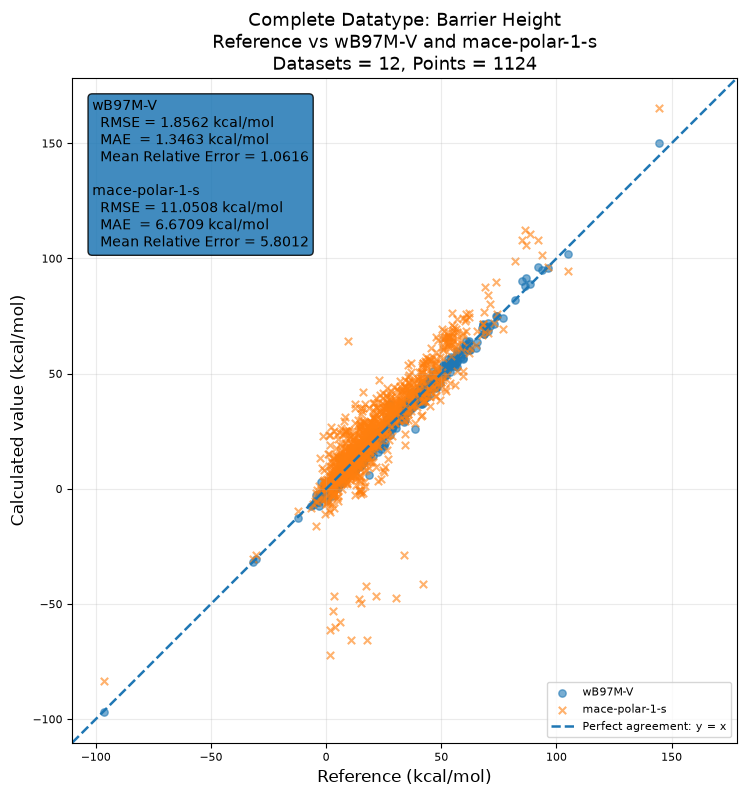

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/figures/barrier_height_Reference_vs_wB97M-V_and_mace-polar-1-m.png


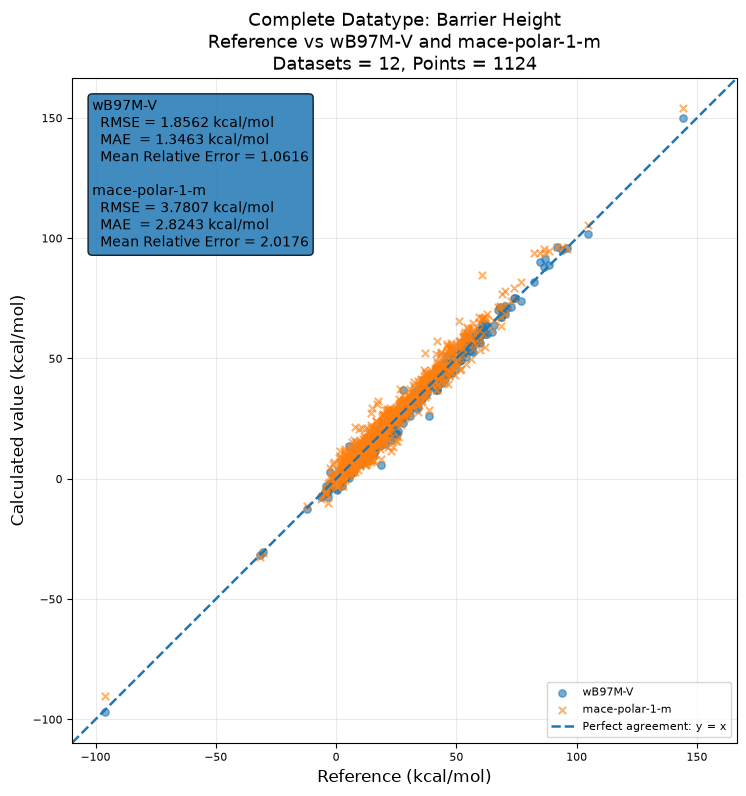

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/MACE_POLAR_DATATYPE/barrier_height/figures/barrier_height_Reference_vs_wB97M-V_and_mace-polar-1-l.png


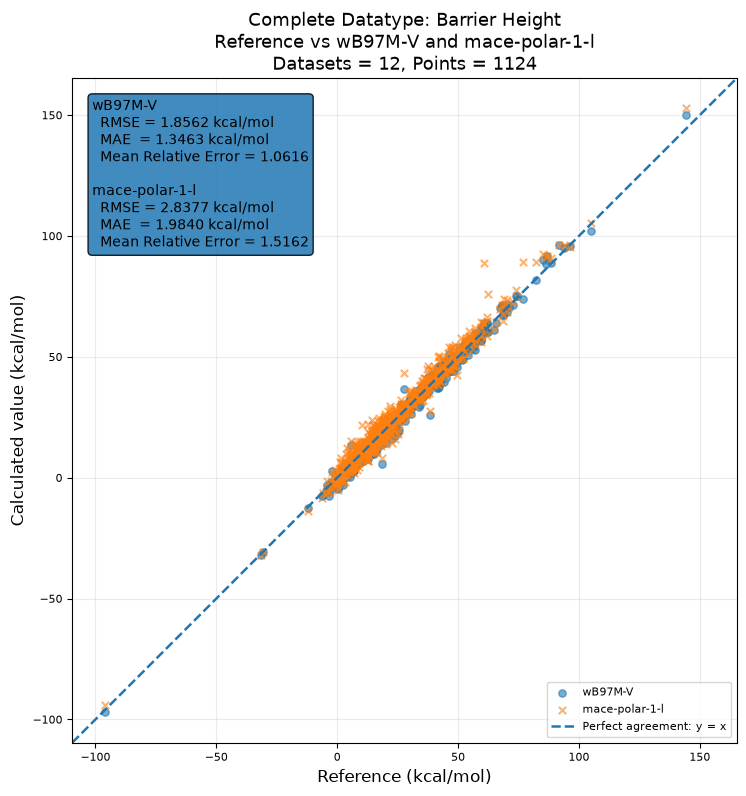

In [14]:
# ============================================================
# 12. THREE COMPLETE-DATATYPE CORRELATION PLOTS
# ============================================================

def plot_complete_datatype(mace_model):
    cols = ["Reference", COMPARATOR, mace_model]
    plot_df = df_datatype_values[cols].apply(
        pd.to_numeric, errors="coerce"
    ).dropna()

    x = plot_df["Reference"].to_numpy()
    y_base = plot_df[COMPARATOR].to_numpy()
    y_mace = plot_df[mace_model].to_numpy()

    all_values = np.concatenate([x, y_base, y_mace])
    vmin = float(np.min(all_values))
    vmax = float(np.max(all_values))
    padding = 0.05 * (vmax - vmin) if vmax > vmin else 1.0
    lo, hi = vmin - padding, vmax + padding

    base_stats = pooled_summary[COMPARATOR]
    mace_stats = pooled_summary[mace_model]

    fig, ax = plt.subplots(figsize=(9, 8))

    ax.scatter(
        x, y_base, s=28, alpha=0.60,
        label=COMPARATOR
    )
    ax.scatter(
        x, y_mace, s=28, alpha=0.60, marker="x",
        label=mace_model
    )

    ax.plot(
        [lo, hi], [lo, hi],
        linestyle="--", linewidth=1.8,
        label="Perfect agreement: y = x"
    )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("Reference (kcal/mol)", fontsize=12)
    ax.set_ylabel("Calculated value (kcal/mol)", fontsize=12)

    ax.set_title(
        f"Complete Datatype: {SELECTED_DATATYPE}\n"
        f"Reference vs {COMPARATOR} and {mace_model}\n"
        f"Datasets = {len(DATATYPE_DATASETS)}, Points = {len(plot_df)}",
        fontsize=13,
    )

    metric_text = (
        f"{COMPARATOR}\n"
        f"  RMSE = {base_stats['RMSE']:.4f} kcal/mol\n"
        f"  MAE  = {base_stats['MAE']:.4f} kcal/mol\n"
        f"  Mean Relative Error = {baseline_mre_calculated:.4f}\n\n"
        f"{mace_model}\n"
        f"  RMSE = {mace_stats['RMSE']:.4f} kcal/mol\n"
        f"  MAE  = {mace_stats['MAE']:.4f} kcal/mol\n"
        f"  Mean Relative Error = {mre_mace[mace_model]:.4f}"
    )

    ax.text(
        0.03, 0.97, metric_text,
        transform=ax.transAxes,
        va="top", ha="left", fontsize=10,
        bbox=dict(boxstyle="round", alpha=0.85),
    )

    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")
    fig.tight_layout()

    if SAVE_PLOTS:
        outfile = FIGURE_DIR / (
            f"{slug}_Reference_vs_{COMPARATOR}_and_{mace_model}.png"
        )
        fig.savefig(outfile, dpi=PLOT_DPI, bbox_inches="tight")
        print("Saved:", outfile)

    plt.show()

for mace_model in MODEL_MAP:
    plot_complete_datatype(mace_model)


## Interpretation and important limitations

For a selected energy Datatype such as **Barrier Height**:

- The correlation plot pools every individual benchmark value from every Dataset in the Datatype.
- Pooled RMSE and pooled MAE therefore weight Datasets in proportion to their numbers of points.
- Mean Relative Error uses a different aggregation:
  1. calculate each Dataset's benchmark metric;
  2. divide it by that Dataset's fixed GSCDB standard metric error;
  3. take the arithmetic mean of those Dataset-level NER values.
- Therefore each Dataset contributes one NER value to the Datatype Mean Relative Error regardless of Dataset size.

### Do not recompute `Standard_errors.csv` after adding MACE-POLAR

The standard error is the fixed GSCDB hybrid-functional baseline. MACE-POLAR is compared *to* that baseline; it is not added to the pool used to redefine the baseline.

### Electric field and Frequency

Do not simply use this energy notebook for `Electric field`. `Dip146`, `Pol130`, `HR46`, `T144`, and `OEEF` require property-specific external-field / finite-difference handling and contain different physical observables, so a single raw pooled correlation plot across mixed units is not physically meaningful.

The NER/MRE framework is still suitable for cross-dataset comparison because it normalizes every Dataset using its own standard error.


In [1]:
from pathlib import Path
import gc, numpy as np, pandas as pd
from tqdm import tqdm
from ase.io import read
from mace.calculators import mace_polar

try:
    import torch
except Exception:
    torch = None

# ============================================================
# SETTINGS
# ============================================================
DATATYPE = "Barrier Height"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = {
    "mace-polar-1-s": "polar-1-s",
    "mace-polar-1-m": "polar-1-m",
    "mace-polar-1-l": "polar-1-l",
}

DEVICE = "cuda" if torch is not None and torch.cuda.is_available() else "cpu"
DTYPE = "float64"
EV_TO_KCAL = 23.06054783

REUSE_EXISTING_MOLECULE_FILE = True
SAVE_EVERY = 20

# ============================================================
# PATHS
# ============================================================
def find_root():
    p = Path.cwd()
    for q in [p, p.parent]:
        if all((q / x).exists() for x in ["Analysis", "Info", "xyz_files", "qchem_inputs"]):
            return q
    raise FileNotFoundError("Run from GSCDB root folder or from GSCDB/Analysis.")

ROOT = find_root()
A, I, X, Q = ROOT / "Analysis", ROOT / "Info", ROOT / "xyz_files", ROOT / "qchem_inputs"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

mol_out = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
mol_log = A / f"Molecule_Energies_MACE_POLAR_Datatype_{TAG}_ALL3_error_log.csv"
rxn_out = A / f"Reaction_Energies_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
val_out = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
err_out = A / f"Results_errors_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"

mae_out = A / f"Errors_per_set_MAE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rmse_out = A / f"Errors_per_set_RMSE_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
metric_out = A / f"Errors_per_set_Metric_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
rel_out = A / f"Relative_metric_per_set_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
long_out = A / f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv"
summary_out = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"

print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("DATATYPE:", DATATYPE)

# ============================================================
# HELPERS
# ============================================================
def reset_calc(calc):
    try: calc.reset()
    except Exception: pass
    try: calc.results = {}
    except Exception: pass
    try: calc.atoms = None
    except Exception: pass

def read_qchem_state(qf):
    charge, spin = 0, 1
    if not qf.exists():
        return charge, spin

    lines = qf.read_text(errors="ignore").splitlines()
    for i, line in enumerate(lines):
        if line.strip().lower() == "$molecule":
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines):
                p = lines[j].split()
                if len(p) >= 2:
                    charge, spin = int(float(p[0])), int(float(p[1]))
            break
    return charge, spin

def prepare_atoms(mol):
    xf, qf = X / f"{mol}.xyz", Q / f"{mol}.in"

    if not xf.exists():
        raise FileNotFoundError(f"Missing xyz file: {xf}")

    charge, spin = read_qchem_state(qf)
    atoms = read(xf)

    charge = int(float(atoms.info.get("charge", charge)))
    spin = int(float(atoms.info.get("multiplicity", atoms.info.get("spin", spin))))

    atoms.info["charge"] = charge
    atoms.info["spin"] = spin

    # Barrier Height is not an electric-field dataset.
    atoms.info["external_field"] = np.array([0.0, 0.0, 0.0], dtype=float)

    return atoms, charge, spin

def mols_from_stoich(st):
    return [p.strip() for p in str(st).split(",")][1::2]

def reaction_energy_kcal(st, df_mol, col):
    p = [x.strip() for x in str(st).split(",")]
    e_ev = 0.0

    for i in range(0, len(p), 2):
        coef, mol = float(p[i]), p[i + 1]

        if mol not in df_mol.index or pd.isna(df_mol.loc[mol, col]):
            return np.nan

        e_ev += coef * float(df_mol.loc[mol, col])

    return e_ev * EV_TO_KCAL

def pooled_metrics(ref, pred):
    d = pd.DataFrame({"x": ref, "y": pred}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)
    e = y - x

    return {
        "N_points": len(x),
        "MAE": np.mean(np.abs(e)) if len(x) else np.nan,
        "RMSE": np.sqrt(np.mean(e ** 2)) if len(x) else np.nan,
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

# ============================================================
# LOAD BASE FILES
# ============================================================
df_eval = pd.read_csv(I / "DatasetEval.csv", index_col=0)
df_info = pd.read_csv(I / "Datasets.csv", index_col=0)
df_rxn_all = pd.read_csv(A / "Reaction_Energies.csv", index_col=0)
df_val_all = pd.read_csv(A / "Results_values.csv", index_col=0)
df_std = pd.read_csv(I / "Standard_errors.csv", index_col=0)

datatype_datasets = df_info.index[df_info["Datatype"] == DATATYPE].tolist()
ev = df_eval[df_eval["Dataset"].isin(datatype_datasets)].copy()

rxn_base = df_rxn_all.loc[ev.index].copy()
val_base = df_val_all.loc[ev.index].copy()

print("\nDatasets in this Datatype:")
print(datatype_datasets)
print("Number of datasets:", len(datatype_datasets))
print("Number of data points:", len(ev))

if len(ev) == 0:
    raise ValueError("No data found. Check whether the Datatype string is exactly 'Barrier Height'.")

all_mols = sorted({m for st in ev["Stoichiometry"] for m in mols_from_stoich(st)})
print("Unique molecules:", len(all_mols))

# ============================================================
# MOLECULE TABLE
# ============================================================
if mol_out.exists() and REUSE_EXISTING_MOLECULE_FILE:
    df_mol = pd.read_csv(mol_out, index_col=0)
    print("\nReusing existing molecule-energy file:")
    print(mol_out)
else:
    rows, missing_xyz = [], []

    for mol in all_mols:
        if not (X / f"{mol}.xyz").exists():
            missing_xyz.append(mol)
            continue

        atoms, charge, spin = prepare_atoms(mol)
        rows.append({
            "Molecule": mol,
            "charge": charge,
            "spin": spin,
            "num_atoms": len(atoms),
        })

    if missing_xyz:
        print("First missing xyz files:", missing_xyz[:20])
        raise FileNotFoundError(f"{len(missing_xyz)} xyz files are missing.")

    df_mol = pd.DataFrame(rows).set_index("Molecule")

for col in MODELS:
    if col not in df_mol.columns:
        df_mol[col] = np.nan

# ============================================================
# MACE-POLAR MOLECULAR ENERGIES
# ============================================================
errors = []

for col, model in MODELS.items():
    print(f"\nLoading {col} -> {model}")
    calc = mace_polar(model=model, device=DEVICE, default_dtype=DTYPE)

    for n, mol in enumerate(tqdm(all_mols, desc=col), start=1):
        if REUSE_EXISTING_MOLECULE_FILE and mol in df_mol.index and pd.notna(df_mol.loc[mol, col]):
            continue

        try:
            atoms, charge, spin = prepare_atoms(mol)
            reset_calc(calc)
            atoms.calc = calc

            df_mol.loc[mol, "charge"] = charge
            df_mol.loc[mol, "spin"] = spin
            df_mol.loc[mol, "num_atoms"] = len(atoms)
            df_mol.loc[mol, col] = float(atoms.get_potential_energy())

        except Exception as exc:
            df_mol.loc[mol, col] = np.nan
            errors.append({"Molecule": mol, "Model": col, "Error": repr(exc)})

        if n % SAVE_EVERY == 0:
            df_mol.to_csv(mol_out)

    df_mol.to_csv(mol_out)
    del calc
    gc.collect()

    if torch is not None and torch.cuda.is_available():
        torch.cuda.empty_cache()

pd.DataFrame(errors).to_csv(mol_log, index=False)
df_mol.to_csv(mol_out)

print("\nMolecule-energy missing values:")
print(df_mol[list(MODELS)].isna().sum())

if len(errors):
    print("\nFirst MACE errors:")
    print(pd.DataFrame(errors).head(20).to_string(index=False))

# ============================================================
# REACTION ENERGIES
# ============================================================
df_rxn = rxn_base.copy()

for rid, row in tqdm(ev.iterrows(), total=len(ev), desc="Barrier Height reaction energies"):
    for col in MODELS:
        df_rxn.loc[rid, col] = reaction_energy_kcal(row["Stoichiometry"], df_mol, col)

df_rxn.to_csv(rxn_out)

print("\nReaction-energy check:")
for col in MODELS:
    print(
        col,
        "| NaN:", df_rxn[col].isna().sum(),
        "| exact zeros:", np.isclose(df_rxn[col].fillna(np.nan), 0.0, equal_nan=False).sum(),
        "| unique:", df_rxn[col].nunique(),
        "| min/max:", df_rxn[col].min(), df_rxn[col].max(),
    )

# ============================================================
# RESULTS VALUES AND ERRORS
# ============================================================
df_val = val_base.copy()

# Barrier Height remains kcal/mol.
for col in MODELS:
    df_val[col] = df_rxn[col]

df_val.to_csv(val_out)

df_err = df_val.copy()
for col in [c for c in df_val.columns if c not in ["Dataset", "Reaction", "Reference"]]:
    df_err[col] = pd.to_numeric(df_val[col], errors="coerce") - pd.to_numeric(df_val["Reference"], errors="coerce")

df_err.to_csv(err_out)

# ============================================================
# DATASET-LEVEL MAE, RMSE, METRIC ERROR, NER / MRE
# For Barrier Height, analyze.ipynb default metric = MAE.
# ============================================================
EVAL_COLS = ["wB97M-V", *MODELS.keys()]

mae_rows, rmse_rows, metric_rows, long_rows = [], [], [], []

for dataset, g_val in df_val.groupby("Dataset"):
    g_err = df_err.loc[g_val.index]
    std_metric = float(df_std.loc[dataset, "Metric"])

    mae_row = {"Dataset": dataset, "Datatype": DATATYPE}
    rmse_row = {"Dataset": dataset, "Datatype": DATATYPE}
    metric_row = {"Dataset": dataset, "Datatype": DATATYPE}

    for col in EVAL_COLS:
        err = pd.to_numeric(g_err[col], errors="coerce")
        complete = err.notna().all()
        n_total = len(err)
        n_used = int(err.notna().sum())

        if complete:
            mae = float(np.mean(np.abs(err)))
            rmse = float(np.sqrt(np.mean(err ** 2)))
            metric_error = mae
            ner = metric_error / std_metric
            status = "COMPLETE"
        else:
            mae = rmse = metric_error = ner = np.nan
            status = "INCOMPLETE"

        mae_row[col] = mae
        rmse_row[col] = rmse
        metric_row[col] = metric_error

        long_rows.append({
            "Dataset": dataset,
            "Datatype": DATATYPE,
            "Model": col,
            "Unit": UNIT,
            "N_total": n_total,
            "N_used": n_used,
            "Status": status,
            "MAE": mae,
            "RMSE": rmse,
            "Metric_Error": metric_error,
            "Standard_Error_Metric": std_metric,
            "NER": ner,
        })

    mae_rows.append(mae_row)
    rmse_rows.append(rmse_row)
    metric_rows.append(metric_row)

df_mae = pd.DataFrame(mae_rows).set_index("Dataset").sort_index()
df_rmse = pd.DataFrame(rmse_rows).set_index("Dataset").sort_index()
df_metric = pd.DataFrame(metric_rows).set_index("Dataset").sort_index()
df_long = pd.DataFrame(long_rows)

df_mae.to_csv(mae_out)
df_rmse.to_csv(rmse_out)
df_metric.to_csv(metric_out)

df_rel = df_metric.copy()
for col in EVAL_COLS:
    df_rel[col] = df_metric[col] / df_std.loc[df_metric.index, "Metric"]

df_rel.to_csv(rel_out)
df_long.to_csv(long_out, index=False)

# ============================================================
# DATATYPE SUMMARY
# ============================================================
summary_rows = []

for col in EVAL_COLS:
    pm = pooled_metrics(df_val["Reference"], df_val[col])
    sub = df_long[df_long["Model"] == col]

    summary_rows.append({
        "Datatype": DATATYPE,
        "Model": col,
        "Unit": UNIT,
        "N_points": pm["N_points"],
        "N_datasets_total": len(sub),
        "N_datasets_complete": int((sub["Status"] == "COMPLETE").sum()),
        "N_datasets_incomplete": int((sub["Status"] == "INCOMPLETE").sum()),
        "Pooled_MAE": pm["MAE"],
        "Pooled_RMSE": pm["RMSE"],
        "Pearson_r": pm["Pearson_r"],
        "Mean_Set_MAE": sub["MAE"].mean(skipna=True),
        "Mean_Set_RMSE": sub["RMSE"].mean(skipna=True),
        "Mean_Relative_Error_NER": sub["NER"].mean(skipna=True),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(summary_out, index=False)

print("\nDatatype summary:")
print(df_summary.to_string(index=False))

# ============================================================
# CHECK wB97M-V MRE AGAINST EXISTING Statistical_errors.csv
# ============================================================
stat_file = A / "Statistical_errors.csv"
row_candidates = [
    f"Mean {DATATYPE}",
    "Mean Barrier Height",
    "Mean BH",
]

if stat_file.exists():
    df_stat = pd.read_csv(stat_file, index_col=0)

    found = False
    for row_name in row_candidates:
        if row_name in df_stat.index and "wB97M-V" in df_stat.columns:
            our = df_summary.loc[df_summary["Model"] == "wB97M-V", "Mean_Relative_Error_NER"].iloc[0]
            old = df_stat.loc[row_name, "wB97M-V"]

            print("\nComparison with existing Statistical_errors.csv:")
            print("Row:", row_name)
            print(f"Our calculated wB97M-V MRE/NER : {our:.10f}")
            print(f"Statistical_errors.csv value   : {old:.10f}")
            print(f"Absolute difference            : {abs(our - old):.3e}")

            found = True
            break

    if not found:
        print("\nStatistical_errors.csv found, but no matching row was found.")
        print("Available rows containing 'Barrier' or 'BH':")
        print([r for r in df_stat.index if "Barrier" in str(r) or str(r) == "BH" or "BH" in str(r)][:30])
else:
    print("\nNo Analysis/Statistical_errors.csv found. Skipped direct comparison.")

print("\nSaved files:")
for f in [mol_out, mol_log, rxn_out, val_out, err_out, mae_out, rmse_out, metric_out, rel_out, long_out, summary_out]:
    print(f)

/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
ROOT: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB
DEVICE: cuda
DATATYPE: Barrier Height

Datasets in this Datatype:
['BH28', 'BH46', 'BH876', 'BHDIV7', 'BHPERI11', 'BHROT27', 'CRBH14', 'DBH22', 'INV23', 'ORBH35', 'PX9', 'WCPT26']
Number of datasets: 12
Number of data points: 1124
Unique molecules: 2125

Loading mace-polar-1-s -> polar-1-s
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Smodel


/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
mace-polar-1-s: 100%|██████████| 2125/2125 [02:11<00:00, 16.15it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-m -> polar-1-m
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Mmodel


mace-polar-1-m: 100%|██████████| 2125/2125 [05:58<00:00,  5.92it/s]
/home/campus.ncl.ac.uk/c5062080/MScProject/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)



Loading mace-polar-1-l -> polar-1-l
Using MACE-Polar model for MACECalculator with /home/campus.ncl.ac.uk/c5062080/.cache/mace/MACEPOLAR1Lmodel


mace-polar-1-l: 100%|██████████| 2125/2125 [14:14<00:00,  2.49it/s]



Molecule-energy missing values:
mace-polar-1-s    0
mace-polar-1-m    0
mace-polar-1-l    0
dtype: int64


Barrier Height reaction energies: 100%|██████████| 1124/1124 [00:00<00:00, 2711.11it/s]


Reaction-energy check:
mace-polar-1-s | NaN: 0 | exact zeros: 0 | unique: 1124 | min/max: -83.33900633511342 165.20350681623066
mace-polar-1-m | NaN: 0 | exact zeros: 0 | unique: 1124 | min/max: -90.45893868300215 154.02005934641323
mace-polar-1-l | NaN: 0 | exact zeros: 0 | unique: 1124 | min/max: -94.04243935537482 152.8118879750411

Datatype summary:
      Datatype          Model     Unit  N_points  N_datasets_total  N_datasets_complete  N_datasets_incomplete  Pooled_MAE  Pooled_RMSE  Pearson_r  Mean_Set_MAE  Mean_Set_RMSE  Mean_Relative_Error_NER
Barrier Height        wB97M-V kcal/mol      1124                12                   12                      0    1.346344     1.856186   0.995460      1.283467       1.710124                 1.061578
Barrier Height mace-polar-1-s kcal/mol      1124                12                   12                      0    6.670928    11.050819   0.882203      7.042811      10.301627                 5.801192
Barrier Height mace-polar-1-m kcal/mol  

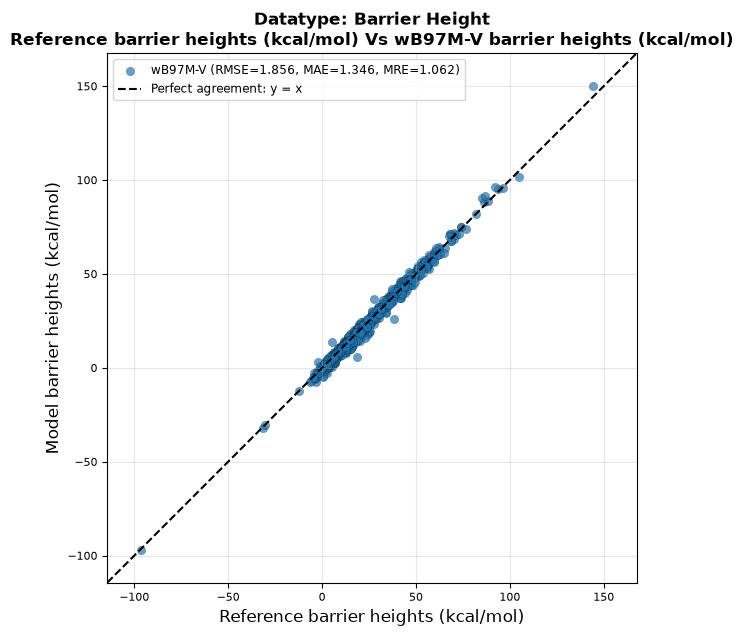

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_Reference_vs_wB97M-V_RMSE_MAE_MRE.png


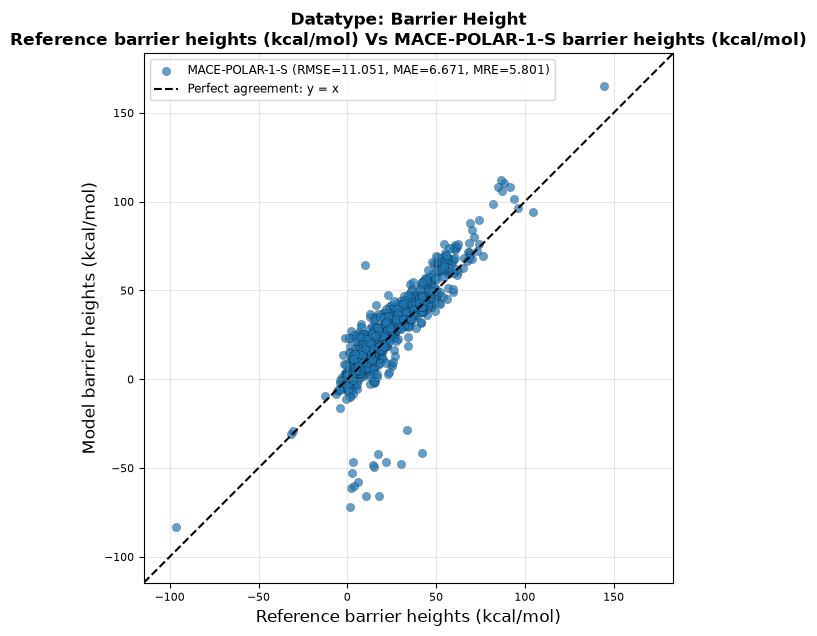

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_Reference_vs_mace-polar-1-s_RMSE_MAE_MRE.png


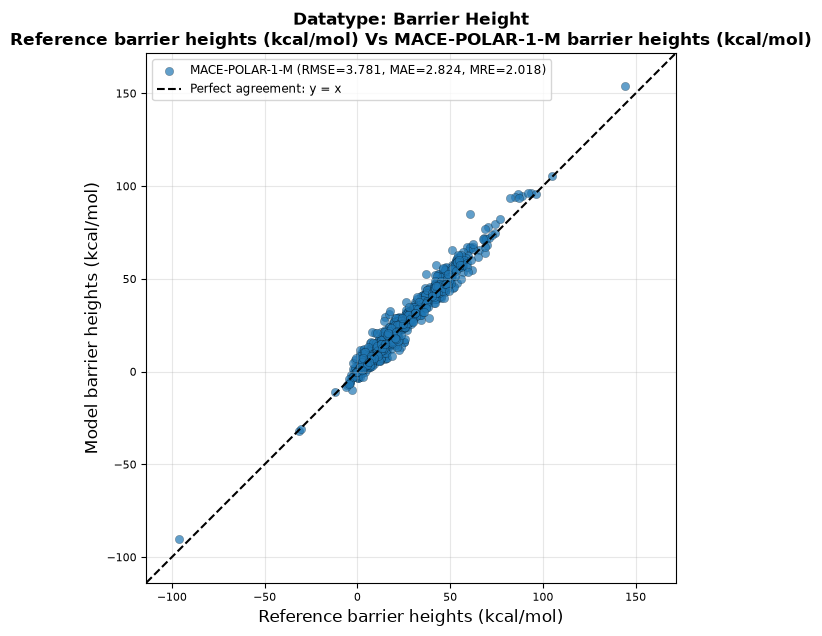

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_Reference_vs_mace-polar-1-m_RMSE_MAE_MRE.png


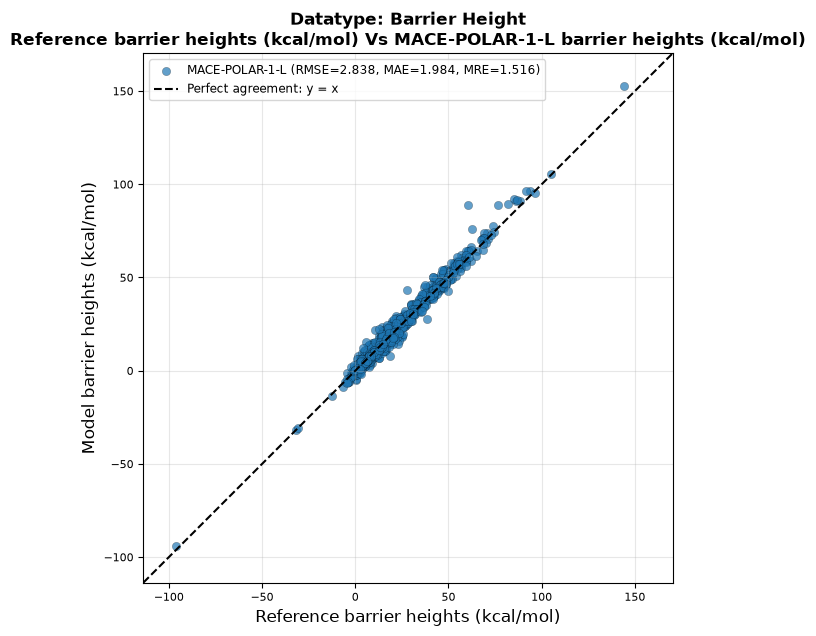

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_Reference_vs_mace-polar-1-l_RMSE_MAE_MRE.png


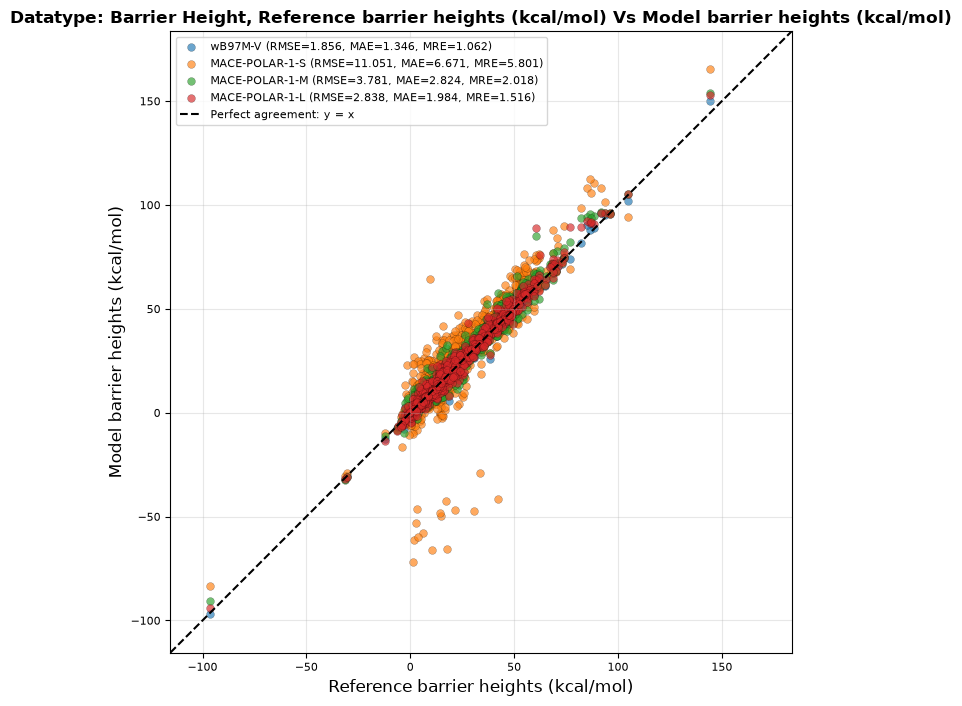

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_all_models_RMSE_MAE_MRE.png


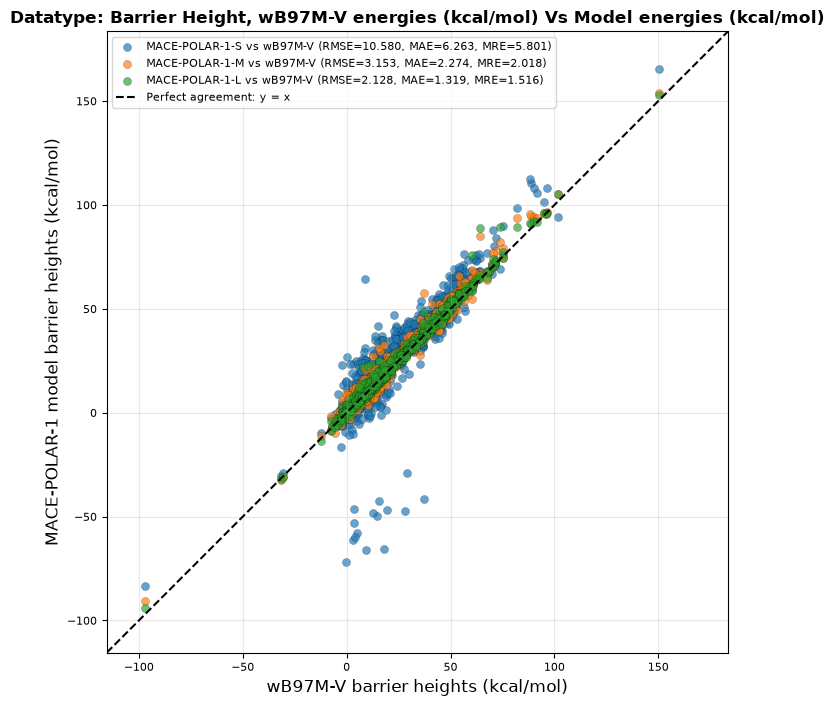

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_wB97M-V_vs_MACE_POLAR_ALL3_RMSE_MAE_MRE.png


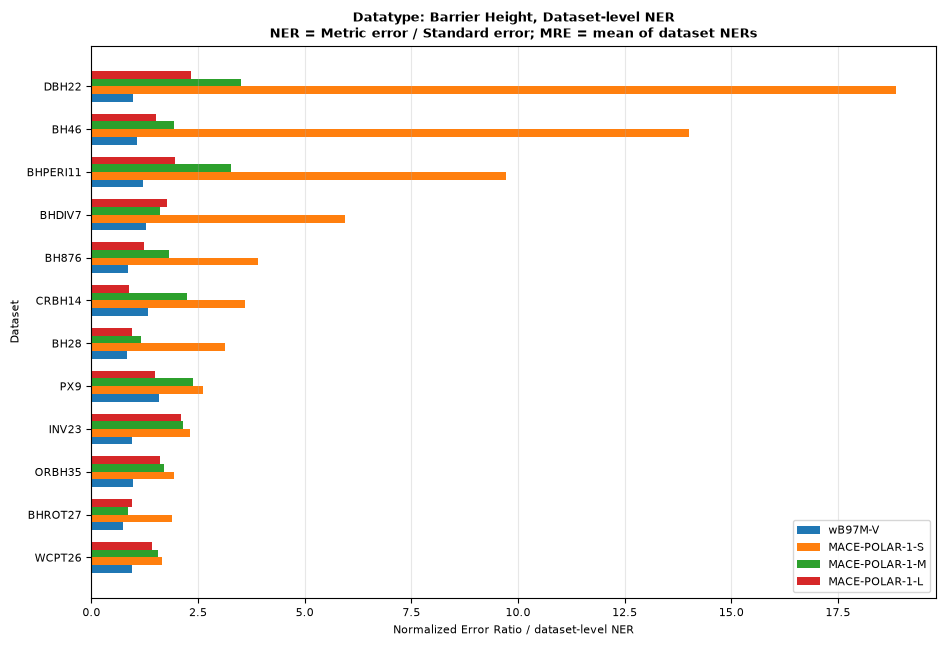

Saved: /home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Figures/Barrier_Height_dataset_level_NER_all_models.png

Saved plot metrics:
/home/campus.ncl.ac.uk/c5062080/MScProject/GSCDB/Analysis/Barrier_Height_correlation_plot_metrics_RMSE_MAE_MRE.csv

Plot metrics:
      Datatype          Model     Unit    N      RMSE      MAE  Mean_Relative_Error_NER  Pearson_r
Barrier Height        wB97M-V kcal/mol 1124  1.856186 1.346344                 1.061578   0.995460
Barrier Height MACE-POLAR-1-S kcal/mol 1124 11.050819 6.670928                 5.801192   0.882203
Barrier Height MACE-POLAR-1-M kcal/mol 1124  3.780685 2.824292                 2.017581   0.984111
Barrier Height MACE-POLAR-1-L kcal/mol 1124  2.837675 1.983982                 1.516238   0.990143


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PLOTS FOR DATATYPE: Barrier Height
# ============================================================
DATATYPE = "Barrier Height"
TAG = DATATYPE.replace(" ", "_")
UNIT = "kcal/mol"

MODELS = ["wB97M-V", "mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]
MACE_ONLY = ["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]

LABELS = {
    "wB97M-V": "wB97M-V",
    "mace-polar-1-s": "MACE-POLAR-1-S",
    "mace-polar-1-m": "MACE-POLAR-1-M",
    "mace-polar-1-l": "MACE-POLAR-1-L",
}

ROOT = Path.cwd()
if not (ROOT / "Analysis").exists():
    ROOT = ROOT.parent

A = ROOT / "Analysis"
FIG = A / "Figures"
FIG.mkdir(exist_ok=True)

val_file = A / f"Results_values_with_MACE_POLAR_Datatype_{TAG}_ALL3.csv"
summary_file = A / f"{TAG}_MACE_POLAR_ALL3_Datatype_Summary.csv"
per_set_file = A / f"{TAG}_MACE_POLAR_ALL3_per_set_metrics_long.csv"

df = pd.read_csv(val_file, index_col=0)
summary = pd.read_csv(summary_file)
per_set = pd.read_csv(per_set_file)

def point_metrics(x, y):
    d = pd.DataFrame({"x": x, "y": y}).dropna()
    x = d["x"].to_numpy(float)
    y = d["y"].to_numpy(float)
    e = y - x

    return {
        "N": len(x),
        "RMSE": np.sqrt(np.mean(e ** 2)),
        "MAE": np.mean(np.abs(e)),
        "Pearson_r": np.corrcoef(x, y)[0, 1] if len(x) > 1 else np.nan,
    }

def get_mre(model):
    return float(summary.loc[summary["Model"] == model, "Mean_Relative_Error_NER"].iloc[0])

def lim(*series):
    values = np.concatenate([
        pd.to_numeric(s, errors="coerce").dropna().to_numpy(float)
        for s in series
    ])

    pad = 0.07 * (values.max() - values.min())
    return values.min() - pad, values.max() + pad

plot_rows = []

# ============================================================
# 1. Individual Reference vs Model plots
# ============================================================
for model in MODELS:
    m = point_metrics(df["Reference"], df[model])
    mre = get_mre(model)

    plot_rows.append({
        "Datatype": DATATYPE,
        "Model": LABELS[model],
        "Unit": UNIT,
        "N": m["N"],
        "RMSE": m["RMSE"],
        "MAE": m["MAE"],
        "Mean_Relative_Error_NER": mre,
        "Pearson_r": m["Pearson_r"],
    })

    lo, hi = lim(df["Reference"], df[model])

    plt.figure(figsize=(7.0, 6.4))

    plt.scatter(
        df["Reference"],
        df[model],
        s=36,
        alpha=0.70,
        edgecolors="black",
        linewidths=0.20,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

    plt.plot(
        [lo, hi],
        [lo, hi],
        "--",
        color="black",
        linewidth=1.5,
        label="Perfect agreement: y = x",
    )

    plt.xlim(lo, hi)
    plt.ylim(lo, hi)
    plt.gca().set_aspect("equal", adjustable="box")

    plt.xlabel("Reference barrier heights (kcal/mol)", fontsize=12)
    plt.ylabel("Model barrier heights (kcal/mol)", fontsize=12)

    plt.title(
        f"Datatype: {DATATYPE}\n"
        f"Reference barrier heights (kcal/mol) Vs {LABELS[model]} barrier heights (kcal/mol)",
        fontsize=12,
        fontweight="bold",
    )

    plt.grid(alpha=0.3)
    plt.legend(fontsize=8.5)
    plt.tight_layout()

    out = FIG / f"{TAG}_Reference_vs_{model}_RMSE_MAE_MRE.png"
    plt.savefig(out, dpi=300)
    plt.show()

    print("Saved:", out)

# ============================================================
# 2. Combined Reference vs all models plot
# ============================================================
lo, hi = lim(df["Reference"], *[df[m] for m in MODELS])

plt.figure(figsize=(7.7, 7.1))

for model in MODELS:
    m = point_metrics(df["Reference"], df[model])
    mre = get_mre(model)

    plt.scatter(
        df["Reference"],
        df[model],
        s=32,
        alpha=0.66,
        edgecolors="black",
        linewidths=0.18,
        label=f"{LABELS[model]} (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("Reference barrier heights (kcal/mol)", fontsize=12)
plt.ylabel("Model barrier heights (kcal/mol)", fontsize=12)

plt.title(
    "Datatype: Barrier Height, "
    "Reference barrier heights (kcal/mol) Vs Model barrier heights (kcal/mol)",
    fontsize=12,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=7.8)
plt.tight_layout()

out = FIG / f"{TAG}_all_models_RMSE_MAE_MRE.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

# ============================================================
# 3. Extra plot:
#    wB97M-V energies Vs MACE-POLAR-1 model energies
# ============================================================
lo, hi = lim(df["wB97M-V"], *[df[m] for m in MACE_ONLY])

plt.figure(figsize=(7.7, 7.1))

for model in MACE_ONLY:
    m = point_metrics(df["wB97M-V"], df[model])
    mre = get_mre(model)

    plt.scatter(
        df["wB97M-V"],
        df[model],
        s=34,
        alpha=0.68,
        edgecolors="black",
        linewidths=0.18,
        label=f"{LABELS[model]} vs wB97M-V (RMSE={m['RMSE']:.3f}, MAE={m['MAE']:.3f}, MRE={mre:.3f})",
    )

plt.plot(
    [lo, hi],
    [lo, hi],
    "--",
    color="black",
    linewidth=1.5,
    label="Perfect agreement: y = x",
)

plt.xlim(lo, hi)
plt.ylim(lo, hi)
plt.gca().set_aspect("equal", adjustable="box")

plt.xlabel("wB97M-V barrier heights (kcal/mol)", fontsize=12)
plt.ylabel("MACE-POLAR-1 model barrier heights (kcal/mol)", fontsize=12)

plt.title(
    "Datatype: Barrier Height, "
    "wB97M-V energies (kcal/mol) Vs Model energies (kcal/mol)",
    fontsize=12,
    fontweight="bold",
)

plt.grid(alpha=0.3)
plt.legend(fontsize=7.7)
plt.tight_layout()

out = FIG / f"{TAG}_wB97M-V_vs_MACE_POLAR_ALL3_RMSE_MAE_MRE.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

# ============================================================
# 4. Dataset-level NER bar plot
# ============================================================
ner = per_set.pivot(index="Dataset", columns="Model", values="NER")
ner = ner[MODELS]

ordered = ner.loc[
    ner[["mace-polar-1-s", "mace-polar-1-m", "mace-polar-1-l"]]
    .max(axis=1)
    .sort_values()
    .index
]

plt.figure(figsize=(9.5, max(6.5, 0.35 * len(ordered))))

y = np.arange(len(ordered))
bar_h = 0.18

for i, model in enumerate(MODELS):
    plt.barh(
        y + (i - 1.5) * bar_h,
        ordered[model],
        height=bar_h,
        label=LABELS[model],
    )

plt.yticks(y, ordered.index)
plt.xlabel("Normalized Error Ratio / dataset-level NER")
plt.ylabel("Dataset")

plt.title(
    "Datatype: Barrier Height, Dataset-level NER\n"
    "NER = Metric error / Standard error; MRE = mean of dataset NERs",
    fontweight="bold",
)

plt.grid(axis="x", alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()

out = FIG / f"{TAG}_dataset_level_NER_all_models.png"
plt.savefig(out, dpi=300)
plt.show()

print("Saved:", out)

# ============================================================
# 5. Save plot metrics
# ============================================================
plot_metrics = pd.DataFrame(plot_rows)
plot_metrics_out = A / f"{TAG}_correlation_plot_metrics_RMSE_MAE_MRE.csv"
plot_metrics.to_csv(plot_metrics_out, index=False)

print("\nSaved plot metrics:")
print(plot_metrics_out)

print("\nPlot metrics:")
print(plot_metrics.to_string(index=False))